## Interpolation

In [1]:
!git clone https://github.com/lanshui98/UniST.git
%cd UniST

Cloning into 'UniST'...
remote: Enumerating objects: 286, done.
remote: Counting objects: 100% (286/286), done.
remote: Compressing objects: 100% (250/250), done.
remote: Total 286 (delta 90), reused 184 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (286/286), 7.40 MiB | 2.40 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/UniST


In [2]:
!pip install -r requirements.txt

  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (60 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached anndata-0.10.9-py3-none-any.whl.metadata (6.9 kB)
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.2.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached markd

#### The example data used for this tutorial can be downloaded from:

https://drive.google.com/drive/folders/1rLF8vWLfOw3xlZzFCfi5X39Rs2W1K5yJ?usp=sharing

#### The pre-trained weight can be downloaded from:

https://drive.google.com/drive/u/1/folders/1zw6kgpnxat_CEFoDWaVIHndxuKqk5vmD

and put under ./external/InterpolAI/interpolation/

In [ ]:
!ls external/InterpolAI/interpolation/model/
!ls external/InterpolAI/interpolation/model/variables

keras_metadata.pb  saved_model.pb  variables
variables.data-00000-of-00001  variables.index


#### Prepare the images

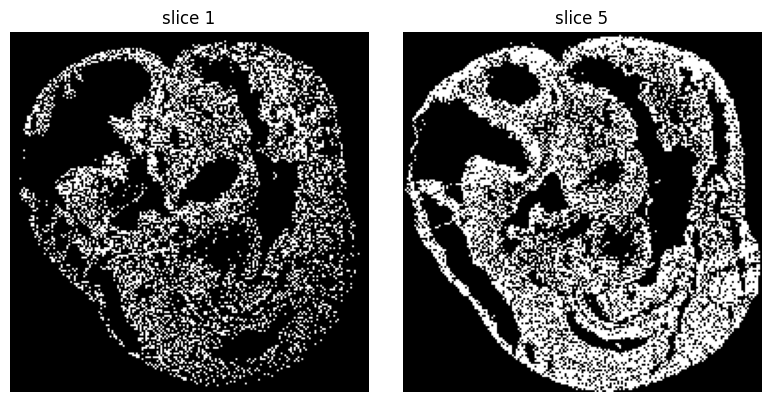

In [8]:
import matplotlib.pyplot as plt
import imageio.v3 as iio
import os
import numpy as np

slice_dir = "occupancy"
slice_ids = [1, 5]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, i in zip(axes, slice_ids):
    file = os.path.join(slice_dir, f"slice{i}.tif")
    image = iio.imread(file)

    ax.imshow(image)
    ax.set_title(f"slice {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# convert into 3 channels
!python -m interpolation.convert_images \
    --input_dir occupancy \
    --output_dir occupancy_3ch

✅ Converted: slice1.tif → (192, 191, 3)
✅ Converted: slice5.tif → (192, 191, 3)

📊 Summary: 2 converted, 0 skipped

✅ Successfully converted 2 image(s)


In [14]:
##### Auto Mode (Automatically Detect Missing Slices)
!python -m interpolation.main \
    --mode auto \
    --tile_size 1024 1024 \
    --pth occupancy_3ch/

2026-02-10 03:56:47.912073: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-10 03:56:47.929561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770695807.950918    8302 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770695807.957392    8302 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770695807.973697    8302 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [16]:
# convert back to single channel
!python -m interpolation.merge_volume \
    --base_dir occupancy \
    --interp_dir occupancy_3ch \
    --out_binary_dir binary_slices \
    --out_stack_path volume.tif \
    --threshold 127

Found 2 base slices and 3 interpolated slices
Total unique indices: 5 (min: 1, max: 5)

 Saved binary slices to: /content/UniST/binary_slices
 Saved volume to: /content/UniST/volume.tif
   Volume shape: (5, 192, 191), dtype: uint8
   Base indices (sample): [1, 5]
   Interp indices (sample): [2, 3, 4]
   All indices range: 1 - 5

✅ Successfully created volume with shape (5, 192, 191)


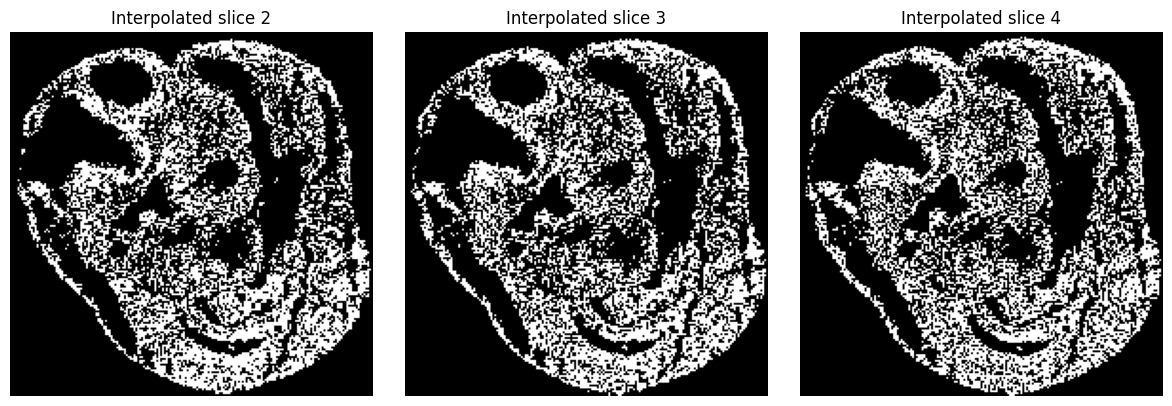

In [21]:
### Visualize results
import os
import imageio.v2 as iio
import matplotlib.pyplot as plt

slice_dir = "binary_slices"

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, i in enumerate(range(2, 5)):
    slice_filename = f"slice_{i:03d}.tif"
    file_path = os.path.join(slice_dir, slice_filename)

    image = iio.imread(file_path)

    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(f"Interpolated slice {i}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

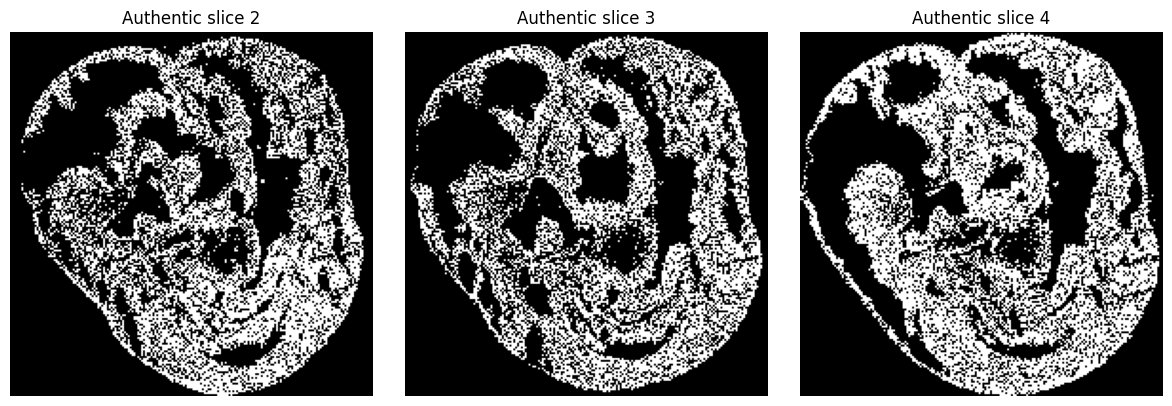

In [23]:
### Visualize authentic slices
import os
import imageio.v2 as iio
import matplotlib.pyplot as plt

slice_dir = "true_slices"

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, i in enumerate(range(2, 5)):
    slice_filename = f"slice{i}.tif"
    file_path = os.path.join(slice_dir, slice_filename)

    image = iio.imread(file_path)

    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(f"Authentic slice {i}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### Alternative method: ReHo (MATLAB based)

##### Run in Python: 

Install MATLAB Engine API for Python (see https://www.mathworks.com/help/matlab/matlab-engine-for-python.html for details);

Image Processing Toolbox is also required for the MATLAB code to run.

In [8]:
import matlab.engine

! python -m interpolation.reho_main \
    --input_dir occupancy \
    --output_dir occupancy_reho \
    --binarize \
    --threshold 127


Starting ReHo interpolation...
  Input directory: occupancy
  Output directory: occupancy_reho
  Parameters: lambda=10, tau=100, max_iter=1000, tol=0.01
iteration 1: error = 0.28402
iteration 2: error = 0.28402
iteration 3: error = 0.28402
iteration 4: error = 0.28402
iteration 5: error = 0.28402
iteration 6: error = 0.28402
iteration 7: error = 0.28402
iteration 8: error = 0.28402
iteration 9: error = 0.28402
iteration 10: error = 0.28402
iteration 11: error = 0.21516
iteration 12: error = 0.18741
iteration 13: error = 0.16397
iteration 14: error = 0.14222
iteration 15: error = 0.11839
iteration 16: error = 0.098233
iteration 17: error = 0.081334
iteration 18: error = 0.068524
iteration 19: error = 0.059122
iteration 20: error = 0.051314
iteration 21: error = 0.046277
iteration 22: error = 0.042317
iteration 23: error = 0.040516
iteration 24: error = 0.039924
iteration 25: error = 0.039924
iteration 26: error = 0.039924
iteration 27: error = 0.039924
iteration 28: error = 0.03946
iter

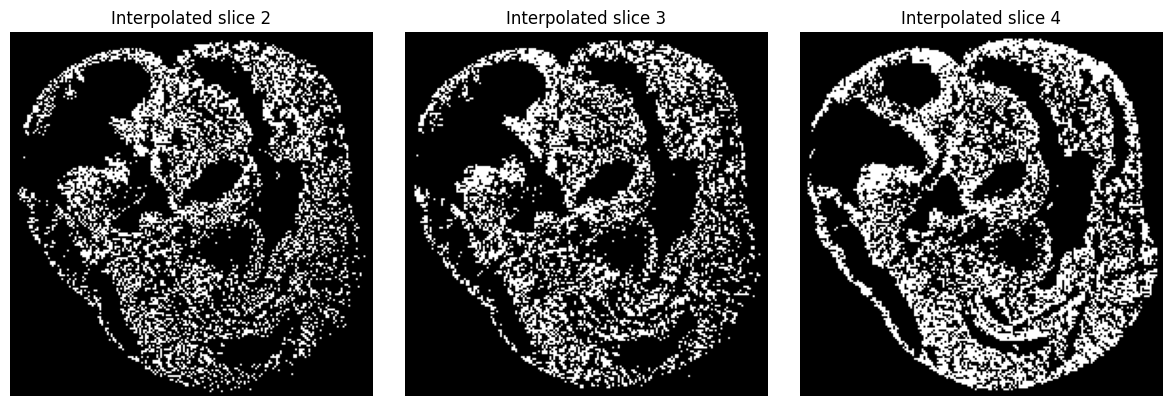

In [9]:
### Visualize results
import os
import imageio.v2 as iio
import matplotlib.pyplot as plt

slice_dir = "occupancy_reho"

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, i in enumerate(range(2, 5)):
    slice_filename = f"slice_{i:03d}.tif"
    file_path = os.path.join(slice_dir, slice_filename)

    image = iio.imread(file_path)

    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(f"Interpolated slice {i}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

##### Run in MATLAB:

Set the path to the MATLAB code: interpolation/ReHo, 

and run the following script in MATLAB command window.

```matlab
inDir = ''; % input path
outDir = ''; % output path
interpolate_missing_slices_spline(inDir, outDir, ...
     'CopyOriginal', true, ... % Copy existing slices to output directory
     'Binarize', true, ... % Treat input as binary mask
     'Thresh', 127, ... % Threshold for binarization (0–255)
     'Lambda', 10, ... % Smoothness regularization parameter
     'Tau', 100, ... % Inter-slice consistency weight
     'TOL', 0.01, ... 
     'MaxIter', 1000, ...
     'BorderSize', 0.1); % Relative border padding size